In [78]:
from deap import tools, creator, base, algorithms, benchmarks
import pymop
from math import factorial
from numpy import random
from meamt_core import generate_dtlz3_front_random, calculate_igd_plus
import numpy
from deap.benchmarks.tools import hypervolume
import numpy as np

PROBLEM = "dtlz3"
NOBJ = 3
K = 10
NDIM = NOBJ + K - 1
P = 12
BOUND_LOW, BOUND_UP = 0.0, 1.0
pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

In [ ]:
MU = 640
NGEN = 500
CXPB = 1.0
MUTPB = 1.0

ref_points_hv = [1.1] * NOBJ
ref_points = tools.uniform_reference_points(NOBJ, P)


In [80]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,) * NOBJ)
creator.create("Individual", list, fitness=creator.FitnessMin)

def uniform(low, up, size=None):
    try:
        return [random.uniform(a, b) for a, b in zip(low, up)]
    except TypeError:
        return [random.uniform(a, b) for a, b in zip([low] * size, [up] * size)]

toolbox = base.Toolbox()
toolbox.register("attr_float", uniform, BOUND_LOW, BOUND_UP, NDIM)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.attr_float)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", benchmarks.dtlz3, obj=NOBJ)
toolbox.register("mate", tools.cxSimulatedBinaryBounded, low=BOUND_LOW, up=BOUND_UP, eta=30.0)
toolbox.register("mutate", tools.mutPolynomialBounded, low=BOUND_LOW, up=BOUND_UP, eta=20.0, indpb=1.0/NDIM)
toolbox.register("select", tools.selNSGA3, ref_points=ref_points)

In [81]:
def main(seed=None):
    random.seed(seed)

    # Initialize statistics object
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", numpy.mean, axis=0)
    stats.register("std", numpy.std, axis=0)
    stats.register("min", numpy.min, axis=0)
    stats.register("max", numpy.max, axis=0)

    logbook = tools.Logbook()
    logbook.header = "gen", "evals", "std", "min", "avg", "max", "hypervolume", "igd_plus"

    pop = toolbox.population(n=MU)

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Compile statistics about the population
    record = stats.compile(pop)
    logbook.record(gen=0, evals=len(invalid_ind), **record)
    print(logbook.stream)

    # Begin the generational process
    for gen in range(1, NGEN):
        offspring = algorithms.varAnd(pop, toolbox, CXPB, MUTPB)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Select the next generation population from parents and offspring
        pop = toolbox.select(pop + offspring, MU)

        # Compile statistics about the new population
        record = stats.compile(pop)
        hv_val = hypervolume(pop, ref_points_hv)
        approx_front = np.array([ind.fitness.values for ind in pop])
        igd_plus_val = calculate_igd_plus(pareto_real, approx_front)
        logbook.record(gen=gen, evals=len(invalid_ind), hypervolume=hv_val,igd_plus=igd_plus_val, **record)
        print(logbook.stream)

    return pop, logbook

In [82]:
pop, logbook = main()

gen	evals	std                                     	min                               	avg                                     	max                                        	hypervolume	igd_plus
0  	640  	[347.95873625 343.284491   362.86246426]	[2.22073132 0.71077674 2.25418562]	[445.55534104 441.86908416 677.55617798]	[1566.90293243 1506.60443375 1760.53496125]	           	        
1  	640  	[365.95982594 375.62458249 324.58364274]	[0.71743062 0.67692926 2.25418562]	[429.13005764 422.27266325 495.61226132]	[1557.47115735 1508.10996866 1578.72137245]	0          	425.521 
2  	640  	[370.13681706 335.46808001 339.88939257]	[0.09538871 0.51574936 2.25418562]	[416.9625296  329.43661453 437.70386372]	[1776.89667844 1506.60443375 1578.72137245]	0          	374.028 
3  	640  	[371.98231434 302.95241334 309.67994934]	[0.05322266 0.38547947 1.76928326]	[420.72709932 273.07169775 355.72393298]	[1776.89667844 1415.06336699 1515.53505617]	0          	291.469 
4  	640  	[360.03269657 264.65402502 309

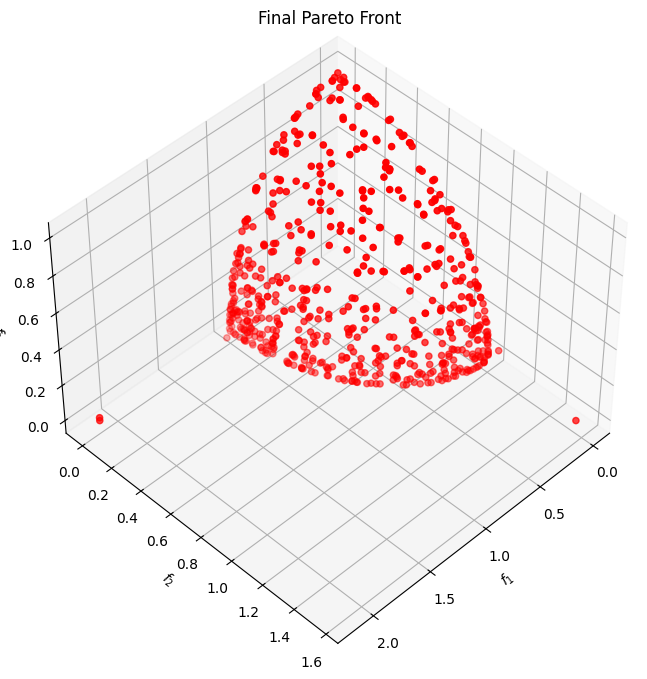

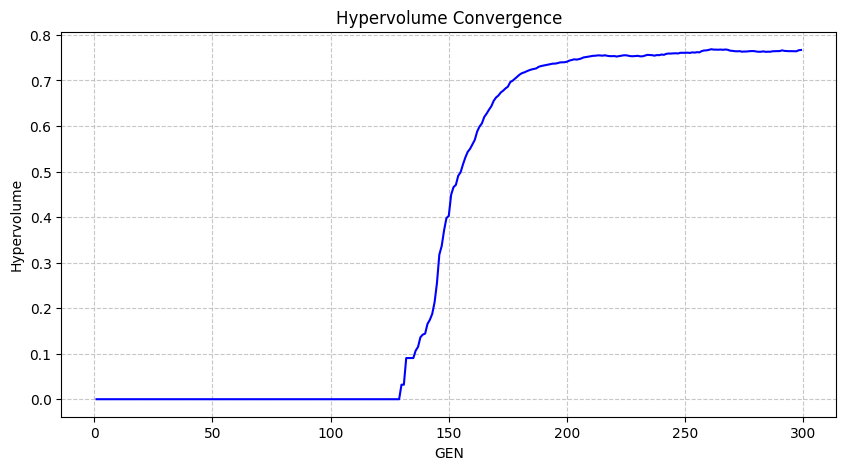

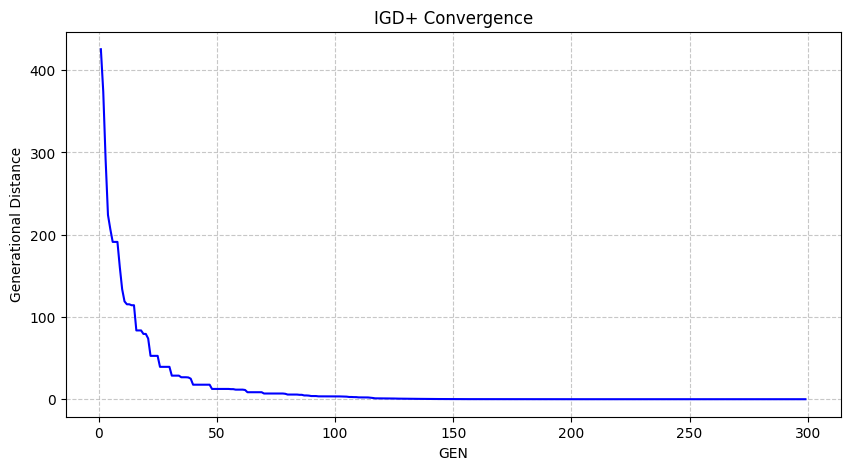

In [83]:
import matplotlib.pyplot as plt

# 3D Graphic of final pareto front
f1 = [ind.fitness.values[0] for ind in pop]
f2 = [ind.fitness.values[1] for ind in pop]
f3 = [ind.fitness.values[2] for ind in pop]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(f1, f2, f3, c='r', marker='o', label='Solutions')
ax.set_title('Final Pareto Front')
ax.set_xlabel('$f_1$')
ax.set_ylabel('$f_2$')
ax.set_zlabel('$f_3$')
ax.view_init(elev=45, azim=45)
plt.show()

# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()